In [5]:
import numpy as np 
import matplotlib.pyplot as plt 
import h5py

In [6]:
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{txfonts}",
})

In [7]:

# Keep the same coordinate limits and color mapping for every run.
AXIS = {"xlim": [-10, 10], "ylim": [-10, 20], "aspect": "equal"}
SPEED_MIN, SPEED_MAX = 25.0, 60.0
CMAP = plt.get_cmap("rainbow")
NORM = plt.Normalize(vmin=SPEED_MIN, vmax=SPEED_MAX)

path = "/Users/ferrone/repos/bar-dynamics/simulations/pal5_bar_pattern_speed_v1/"
fname = "pal5__mw-fiducial_v1__lookback-4gyr__n-512__s-0042__75958ac3__bar-ferrers_v1__omega-cw-050.0.h5"
myfile = h5py.File(path+fname,mode="r")

pattern_speed = float(myfile.attrs["bar_pattern_speed_magnitude_kms_kpc"])
phase_space = myfile["stream/phase_space"][:]

In [13]:
myfile['progenitor'].keys()

<KeysViewHDF5 ['orbit_phase_space', 'present_phase_space']>

In [10]:
for key in myfile.attrs.keys():
    print(key)

agama_version
axisymmetric_control
bar_model_id
bar_pattern_speed_magnitude_kms_kpc
bar_pattern_speed_signed_kms_kpc
bar_present_angle_deg
cluster_mass_msun
experiment_config_ini
experiment_id
h5py_version
initial_conditions_txt
lookback_gyr
milky_way_model_id
numpy_version
orbit_integrator
particle_count
phase_space_column_order
random_seed
rotation_direction
run_type
schema_version
stream_generation_method
stream_id
units


In [4]:
def make_stream_figure(
    phase_space,
    pattern_speed,
    *,
    norm,
    cmap,
    xlim=(-10, 10),
    ylim=(-10, 20),
    width_mm=88,
):
    # width_mm is for a single column in a two-column paper 

    # Margins include room for 11 pt labels and colorbar ticks/label.
    left_mm = 16
    right_mm = 15
    top_mm = 8
    bottom_mm = 14
    colorbar_width_mm = 2.5
    gap_mm = 0

    x_span = xlim[1] - xlim[0]
    y_span = ylim[1] - ylim[0]
    axes_width_mm = (
        width_mm - left_mm - right_mm - colorbar_width_mm - gap_mm
    )
    axes_height_mm = axes_width_mm * y_span / x_span
    height_mm = top_mm + axes_height_mm + bottom_mm

    fig = plt.figure(figsize=(width_mm / 25.4, height_mm / 25.4))
    
    axis = fig.add_axes([
        left_mm / width_mm,
        bottom_mm / height_mm,
        axes_width_mm / width_mm,
        axes_height_mm / height_mm,
    ])
    
    color_axis = fig.add_axes([
        (left_mm + axes_width_mm + gap_mm) / width_mm,
        bottom_mm / height_mm,
        colorbar_width_mm / width_mm,
        axes_height_mm / height_mm,
    ])

    axis.scatter(
        phase_space[:, 1],
        phase_space[:, 2],
        s=3,
        color=cmap(norm(pattern_speed)),
        linewidths=0,
    )
    axis.set(
        xlim=xlim,
        ylim=ylim,
        xlabel=r"$y$ [$\rm{kpc}$]",
        ylabel=r"$z$ [$\rm{kpc}$]",
    )
    axis.set_aspect("equal", adjustable="box")

    mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    cbar=fig.colorbar(
        mappable,
        cax=color_axis,
        label=r"$|\Omega_\mathrm{bar}|$ [km s$^{-1}$ kpc$^{-1}$]",
    )
        
    cbar.ax.axhline(
        pattern_speed,
        color="black",
        linewidth=3,
        xmin=0,
        xmax=1,
        zorder=10,
    )
    return fig, axis

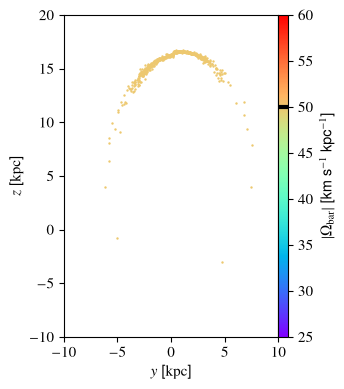

In [5]:
make_stream_figure(phase_space, pattern_speed, norm=NORM, cmap=CMAP);